# 3 — Explore longitudinal growth

**Snapshot:** reviewed analysis cells have been added after the clean-table step.

These are exploratory, descriptive views of synthetic data. They are not evidence that a program, teacher, or student caused a change. Scale-score interpretation should follow the assessment's technical guidance.

## Rebuild the vetted local analysis table

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 20)


def locate_data_file(filename):
    """Find a data file when the notebook starts in /notebooks or the project root."""
    for folder in (Path.cwd(), Path.cwd().parent):
        candidate = folder / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename!r} in the current folder or its parent.")


reading_path = locate_data_file("FakeiReadyData.csv")
math_path = locate_data_file("FakeiReadyMathData.csv")

# Read identifiers as strings so leading zeros would be preserved in a real export.
reading_raw = pd.read_csv(
    reading_path,
    dtype={"Student Id": "string", "Class": "string"},
)
math_raw = pd.read_csv(
    math_path,
    dtype={"Student Id": "string", "Class": "string"},
)


SEASONS = ["Fall", "Winter", "Spring"]


def assessment_column(subject, measure, season):
    """Build the exact multiline heading used by the source CSV files."""
    return f"I-Ready Result\n{subject}\n{measure} - {season}\n2025-2026"


# Validate the proposed one-to-one join without displaying identifiers.
reading_ids = set(reading_raw["Student Id"].dropna())
math_ids = set(math_raw["Student Id"].dropna())
id_sets_match = reading_ids == math_ids

reading_demo = reading_raw.set_index("Student Id")
math_demo = math_raw.set_index("Student Id").rename(columns={"LEP": "MLL"})
demo_fields = [
    "Student Name", "Gender", "SWD", "MLL", "ED", "Current Grade", "Class"
]
if id_sets_match:
    mismatch_count = int(
        (
            reading_demo[demo_fields].sort_index().astype("string")
            != math_demo[demo_fields].sort_index().astype("string")
        ).sum().sum()
    )
else:
    mismatch_count = -1

validation = pd.DataFrame(
    {
        "check": [
            "Reading IDs are present and unique",
            "Math IDs are present and unique",
            "Reading and math ID sets match",
            "Shared demographic fields agree",
        ],
        "passed": [
            reading_raw["Student Id"].notna().all()
            and not reading_raw["Student Id"].duplicated().any(),
            math_raw["Student Id"].notna().all()
            and not math_raw["Student Id"].duplicated().any(),
            id_sets_match,
            mismatch_count == 0,
        ],
    }
)
assert validation["passed"].all(), "Stop and resolve join validation failures before analysis."

# Build stable aliases for this session. This is pseudonymization, not anonymization.
key_map = {
    student_id: f"S{number:03d}"
    for number, student_id in enumerate(sorted(reading_ids), start=1)
}

demographics = (
    reading_raw.assign(student_key=reading_raw["Student Id"].map(key_map))
    .rename(
        columns={
            "Gender": "gender",
            "SWD": "swd",
            "MLL": "mll",
            "ED": "economically_disadvantaged",
            "Current Grade": "current_grade",
            "Class": "class_section",
        }
    )[
        [
            "student_key",
            "gender",
            "swd",
            "mll",
            "economically_disadvantaged",
            "current_grade",
            "class_section",
        ]
    ]
)


def extract_scores(raw, subject):
    """Return one row per student and season for one subject."""
    frames = []
    prefix = subject.lower()
    for season in SEASONS:
        selected = raw[
            [
                "Student Id",
                assessment_column(subject, "Overall SS", season),
                assessment_column(subject, "Percentile", season),
                assessment_column(subject, "Overall Placement", season),
            ]
        ].copy()
        selected.columns = [
            "student_id",
            f"{prefix}_score",
            f"{prefix}_percentile",
            f"{prefix}_placement",
        ]
        selected["student_key"] = selected["student_id"].map(key_map)
        selected["season"] = season
        frames.append(selected.drop(columns="student_id"))
    return pd.concat(frames, ignore_index=True)


reading_scores = extract_scores(reading_raw, "Reading")
math_scores = extract_scores(math_raw, "Math")

analysis = (
    reading_scores.merge(
        math_scores,
        on=["student_key", "season"],
        how="inner",
        validate="one_to_one",
    )
    .merge(demographics, on="student_key", how="left", validate="many_to_one")
)
analysis["season"] = pd.Categorical(
    analysis["season"], categories=SEASONS, ordered=True
)
analysis = analysis.sort_values(["student_key", "season"]).reset_index(drop=True)

quality_checks = pd.DataFrame(
    {
        "check": [
            "Expected student-season row count",
            "One row per student and season",
            "Every student has all three seasons",
            "No direct identifiers in analysis table",
            "No missing overall scores",
        ],
        "passed": [
            len(analysis) == len(reading_ids) * len(SEASONS),
            not analysis.duplicated(["student_key", "season"]).any(),
            analysis.groupby("student_key", observed=True)["season"].nunique().eq(3).all(),
            {"Student Id", "Student Name"}.isdisjoint(analysis.columns),
            analysis[["reading_score", "math_score"]].notna().all().all(),
        ],
    }
)
assert quality_checks["passed"].all(), "Stop and resolve preparation failures before analysis."

In [2]:
print(
    f"Prepared {len(analysis):,} student-season rows for "
    f"{analysis['student_key'].nunique():,} matched synthetic students."
)

Prepared 180 student-season rows for 60 matched synthetic students.


## Question 1: How did cohort averages move across seasons?

A longitudinal line chart is a useful first view, but means can hide variation. The y-axis is intentionally labeled and does not imply that zero is a meaningful scale-score origin.

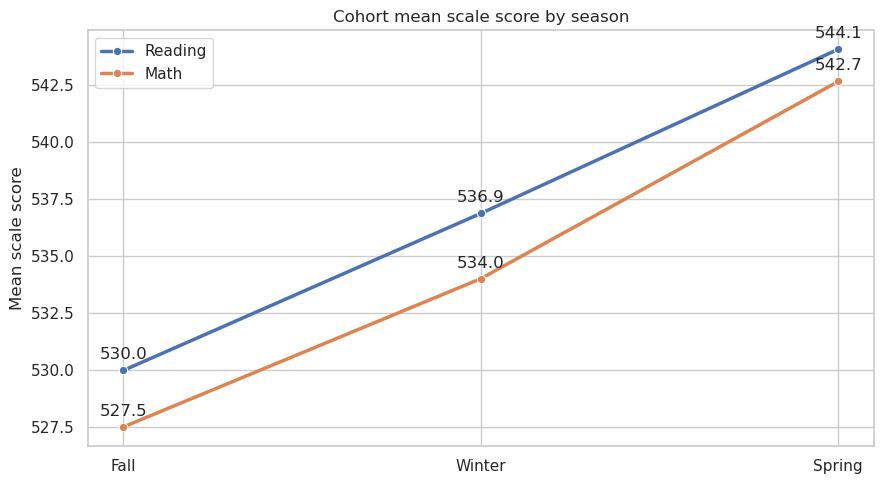

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

trend = (
    analysis.groupby("season", observed=True)[["reading_score", "math_score"]]
    .mean()
    .rename(columns={"reading_score": "Reading", "math_score": "Math"})
    .reset_index()
    .melt(id_vars="season", var_name="subject", value_name="mean_score")
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=trend,
    x="season",
    y="mean_score",
    hue="subject",
    marker="o",
    linewidth=2.5,
    ax=ax,
)
for row in trend.itertuples():
    ax.annotate(
        f"{row.mean_score:.1f}",
        (row.season, row.mean_score),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )
ax.set(title="Cohort mean scale score by season", xlabel="", ylabel="Mean scale score")
ax.legend(title="")
plt.tight_layout()
plt.show()

## Question 2: What does paired Fall-to-Spring growth look like?

We pivot within student before subtracting. That avoids mistaking a change in the tested cohort for within-student growth.

In [4]:
student_columns = [
    "student_key",
    "gender",
    "swd",
    "mll",
    "economically_disadvantaged",
    "current_grade",
    "class_section",
]
student_info = analysis[student_columns].drop_duplicates()

score_wide = analysis.pivot(
    index="student_key",
    columns="season",
    values=["reading_score", "math_score"],
)
score_wide.columns = [
    f"{subject}_{season.lower()}" for subject, season in score_wide.columns
]

growth = student_info.merge(score_wide.reset_index(), on="student_key", validate="one_to_one")
growth["reading_growth"] = growth["reading_score_spring"] - growth["reading_score_fall"]
growth["math_growth"] = growth["math_score_spring"] - growth["math_score_fall"]

In [5]:
growth_summary = pd.DataFrame(
    {
        "Reading": growth["reading_growth"].describe(),
        "Math": growth["math_growth"].describe(),
    }
).loc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(1)
growth_summary

,Reading,Math
count,60.0,60.0
mean,14.1,15.2
std,4.1,4.1
min,8.0,8.0
25%,11.0,12.8
50%,13.0,15.0
75%,16.2,17.2
max,24.0,24.0


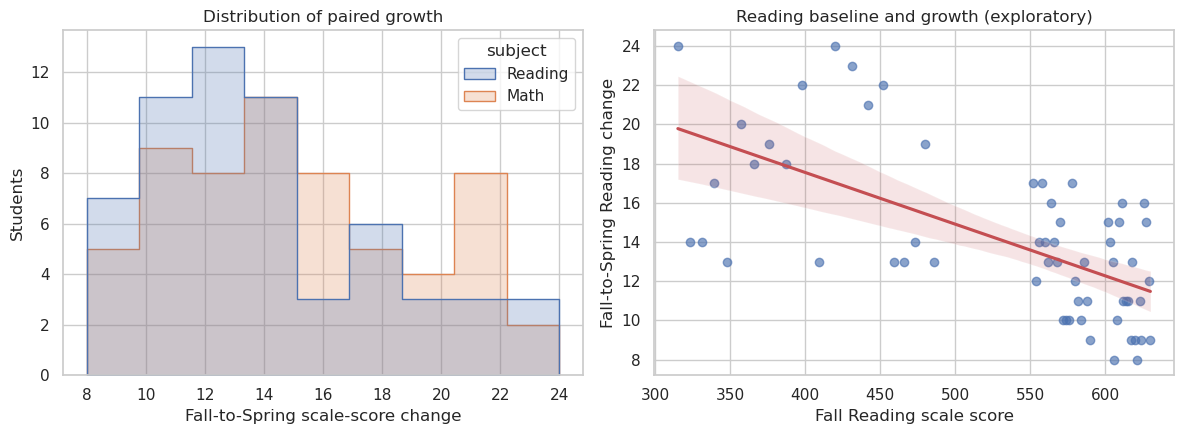

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

growth_long = growth[["reading_growth", "math_growth"]].rename(
    columns={"reading_growth": "Reading", "math_growth": "Math"}
).melt(var_name="subject", value_name="fall_to_spring_growth")
sns.histplot(
    data=growth_long,
    x="fall_to_spring_growth",
    hue="subject",
    element="step",
    bins=9,
    common_norm=False,
    ax=axes[0],
)
axes[0].set(
    title="Distribution of paired growth",
    xlabel="Fall-to-Spring scale-score change",
    ylabel="Students",
)

sns.regplot(
    data=growth,
    x="reading_score_fall",
    y="reading_growth",
    scatter_kws={"alpha": 0.65},
    line_kws={"color": "#C44E52"},
    ax=axes[1],
)
axes[1].set(
    title="Reading baseline and growth (exploratory)",
    xlabel="Fall Reading scale score",
    ylabel="Fall-to-Spring Reading change",
)

plt.tight_layout()
plt.show()

**Interpret with care:** a baseline/growth relationship can reflect measurement error, ceiling effects, regression to the mean, or other factors. This chart does not estimate a causal effect. It is appropriate for local exploration, but an individual-point chart should not be screen-shared with real student data.

## Question 3: Are there descriptive subgroup patterns worth investigating?

The notebook computes locally, then suppresses displayed means for every subgroup with fewer than 10 students. Suppression is only one safeguard; it does not by itself make an output safe to publish.

In [7]:
MIN_GROUP_SIZE = 10
subgroup_frames = []
for dimension, label in [
    ("gender", "Gender"),
    ("swd", "Students with disabilities"),
    ("mll", "Multilingual learners"),
    ("economically_disadvantaged", "Economically disadvantaged"),
]:
    part = (
        growth.groupby(dimension, dropna=False)
        .agg(
            n=("student_key", "size"),
            reading_growth=("reading_growth", "mean"),
            math_growth=("math_growth", "mean"),
        )
        .reset_index()
        .rename(columns={dimension: "group"})
    )
    part.insert(0, "dimension", label)
    subgroup_frames.append(part)

subgroup_internal = pd.concat(subgroup_frames, ignore_index=True)
eligible = subgroup_internal["n"].ge(MIN_GROUP_SIZE)
subgroup_display = subgroup_internal.assign(
    n=subgroup_internal["n"].astype("string").where(eligible, f"<{MIN_GROUP_SIZE}"),
    reading_growth=subgroup_internal["reading_growth"].where(eligible),
    math_growth=subgroup_internal["math_growth"].where(eligible),
)

In [8]:
subgroup_display.style.format(
    {"reading_growth": "{:.1f}", "math_growth": "{:.1f}"},
    na_rep="suppressed",
).hide(axis="index")

dimension,group,n,reading_growth,math_growth
Gender,F,29,14.5,15.6
Gender,M,29,13.9,14.7
Gender,O,<10,suppressed,suppressed
Students with disabilities,No,48,13.8,15.0
Students with disabilities,Yes,12,15.4,15.8
Multilingual learners,No,50,14.5,15.5
Multilingual learners,Yes,10,12.2,13.5
Economically disadvantaged,No,24,13.9,16.0
Economically disadvantaged,Yes,36,14.3,14.6


### Questions these results can raise—not answer

- Are differences stable across years or assessment windows?
- Are the groups comparable in baseline score, opportunity to learn, and participation?
- Is a scale-score change educationally meaningful under vendor guidance?
- What contextual knowledge do educators have that is absent from this export?

Avoid ranking classes or treating descriptive gaps as effects of an identity or service status.

## Prompt 3 — turn vetted analyses into an aggregate presentation view

This prompt names local objects and design constraints. It sends neither records nor calculated values.

In [9]:
prompt_3 = """
I have already reviewed and run local Python code that creates these objects:
- `analysis`: one pseudonymous student-season row;
- `growth`: one pseudonymous student row with Fall/Spring scores and growth;
- `subgroup_internal`: subgroup n and mean growth;
- `MIN_GROUP_SIZE = 10`.

Do not ask me to send data or output. Write presentation-ready pandas/
matplotlib/seaborn code for a 2x2 aggregate dashboard:
A. cohort mean Reading/Math scale-score trend;
B. Spring placement percentages by subject in logical grade order;
C. Reading/Math Fall-to-Spring growth boxplots with outlier points hidden;
D. subgroup mean growth bars, excluding n < MIN_GROUP_SIZE.

Add a small KPI table and 3 automatically calculated, plain-language bullets.
Keep titles descriptive, state that results are synthetic/descriptive, make no
causal claims, do not rank classes, do not label students, and do not save or
transmit anything. Return one Python code block plus a short markdown caption.
""".strip()

print(prompt_3)

I have already reviewed and run local Python code that creates these objects:
- `analysis`: one pseudonymous student-season row;
- `growth`: one pseudonymous student row with Fall/Spring scores and growth;
- `subgroup_internal`: subgroup n and mean growth;
- `MIN_GROUP_SIZE = 10`.

Do not ask me to send data or output. Write presentation-ready pandas/
matplotlib/seaborn code for a 2x2 aggregate dashboard:
A. cohort mean Reading/Math scale-score trend;
B. Spring placement percentages by subject in logical grade order;
C. Reading/Math Fall-to-Spring growth boxplots with outlier points hidden;
D. subgroup mean growth bars, excluding n < MIN_GROUP_SIZE.

Add a small KPI table and 3 automatically calculated, plain-language bullets.
Keep titles descriptive, state that results are synthetic/descriptive, make no
causal claims, do not rank classes, do not label students, and do not save or
transmit anything. Return one Python code block plus a short markdown caption.


### What to copy back

Copy the reviewed dashboard code into a new code cell. Keep any caveats as markdown immediately above or below the chart. The result of that review is shown in **`04_presentation_view.ipynb`**.